In [1]:
from graph_transformer_long_range_niches.tl.wandb import load_and_log
from graph_transformer_long_range_niches.tl.load_config import Config
from graph_transformer_long_range_niches._paths import CFG_FILES
from graph_transformer_long_range_niches.model.gnn_transformer import LitGNNTransformer
from graph_transformer_long_range_niches.tl.utils import pad_batch

from pathlib import Path
import wandb
import torch
import os

## plotting
import matplotlib.pyplot as plt
import seaborn as sns

## Utility functions

In [34]:
def read(data_dir, split):
    """ Read PyG data from artifact folder
    """
    filename = split + ".pt"
    pyg_data = torch.load(os.path.join(data_dir, filename))
    return pyg_data # list with PyG Data objects

## Set global parameters

In [3]:
data_dir = '/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/docs/notebooks/artifacts/he23_niche_window:v0'
cfg_path = Path(CFG_FILES, 'He23/he23_gnntrans_niche.yaml')

In [4]:
artifact_dir = '/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/docs/notebooks/artifacts/model-srw7c0r8:v99'
data_dir = '/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/docs/notebooks/artifacts/he23_niche_window:v0'

# Load data and model checkpoint

In [5]:
cfg_path = Path(CFG_FILES, 'He23/he23_gnntrans_niche.yaml')
cfg = Config(cfg_path)

Load cfg file...
{'out_dir': 'results', 'wandb': {'use': True, 'project_name': 'GTLongRange', 'run_idx': None}, 'model': {'model_type': 'gnn-transformer', 'n_epochs': 100}, 'optim': {'lr': 0.001, 'wd': '1e-3', 'warm_up': 10, 'seed': 42}, 'dataset': {'h5ad_data': '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/unprocessed_data/he22_cosmx_human_lung.h5ad', 'name': 'he23', 'description': "CosmX Lung data from He23 with graphs for each .obs['sliding_window'] and prediction node .obs['niche'].", 'prediction_task': 'node', 'prediction_obs': 'niche', 'library_key': 'sliding_window', 'subset_dict': {}, 'spatial_neigbors_kwargs': {'radius': 50, 'coord_type': 'generic'}, 'batch_size': 20, 'train_size': 0.8, 'val_size': 0.2, 'test_size': 0.0}, 'gnn': {'gnn_type': 'GCN', 'num_layers': 2, 'hidden_dim': 256, 'embed_dim': 256, 'dropout': 0.1}, 'transformer': {'d_model': 128, 'n_heads': 4, 'dim_feedforward': 512, 'dropout': 0.3, 'num_layers': 4, 'activation_func': 'relu', 'n

In [6]:
model_path = f'{artifact_dir}/model.ckpt'
checkpoint = torch.load(model_path)
cfg = checkpoint['hyper_parameters']['cfg']
model = LitGNNTransformer(cfg)

/home/icb/francesca.drummer/tools/apps/mamba/envs/exphormer_mamba/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [7]:
model.load_state_dict(checkpoint['state_dict'])
pyg_data_val = read(data_dir, 'validation')
pyg_data_val[:3]

[Data(x=[1775, 960], edge_index=[2, 32], y=[1775, 9]),
 Data(x=[3517, 960], edge_index=[2, 1906], y=[3517, 9]),
 Data(x=[457, 960], edge_index=[2, 38], y=[457, 9])]

# Attention matrix

`.self_attn` get [PyTorch MultiheadAttention](https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html)

- attention is averaged across heads of one layer
- forward():
    - Out: 
        - `attn_output`: unbatched: (L, E) or batched: (L, B, E) with L = target sequence length, B = batch size, E = embedding dimension
          - The transformed input data after applying multi-head attention, useful for the next layers in the model.
        - `attn_output_weights`: attention weights averaged across heads of shape (L,S)(L,S) when input is unbatched or (N,L,S)(N,L,S), where NN is the batch size, L is the target sequence length, and S is the source sequence length.
          -  The weights showing how much each input element contributes to the output, useful for interpretability and understanding the attention mechanism.

In [36]:
def eval(self, batched_data):
    h_node, z = self.gnn(batched_data.x, batched_data.edge_index)
    h_node = self.gnn2transformer(h_node) 
    padded_h_node, src_padding_mask, index_nodes, num_nodes, mask, max_num_nodes = pad_batch(
            h_node, batched_data.batch, self.transformer_encoder.max_input_len, get_mask=True
        )
    transformer_out, src_padding_mask = self.transformer_encoder(padded_h_node, src_padding_mask)
    return padded_h_node, transformer_out, src_padding_mask, index_nodes


In [9]:
def extract_attention(self, x, src_padding_mask):
    """Returns a list of attention maps (Tensor) for each Transformer layer.
    """
    attn_weights_maps = []
    attn_maps = []
        
    num_layers = self.transformer_encoder.num_layers
    num_heads = self.transformer_encoder.layers[0].self_attn.num_heads
    norm_first = self.transformer_encoder.layers[0].norm_first

    with torch.no_grad():
        for i in range(num_layers):
            # compute attention of layer i
            h = x.clone()
            if norm_first:
                h = self.transformer_encoder.layers[i].norm1(h)
            attn_output, attn_output_weights = self.transformer_encoder.layers[i].self_attn(h, h, h, need_weights=True, key_padding_mask=src_padding_mask)
            attn_maps.append(attn_output)
            attn_weights_maps.append(attn_output_weights)
            # forward of layer i
            x = self.transformer_encoder.layers[i](x)
            
        # attention_maps = torch.stack(attention_maps, dim=0)
        # attention_maps = torch.mean(attention_maps, dim=0)
        
    return attn_maps, attn_weights_maps

In [10]:
from torch_geometric.loader import DataLoader
eval_loader = DataLoader(pyg_data_val[:3], 1)

In [39]:
for batch in eval_loader:
    print(batch)
    transformer_in, transformer_out, src_padding_mask, index_nodes = eval(model, batch)
    print(f'transformer in: {transformer_in.shape}, out: {transformer_out.shape}')
    attn_maps, attn_weights_maps = extract_attention(model.transformer_encoder, transformer_out, src_padding_mask)

DataBatch(x=[1775, 960], edge_index=[2, 32], y=[1775, 9], batch=[1775], ptr=[2])
transformer in: torch.Size([1000, 1, 128]), out: torch.Size([1001, 1, 128])
DataBatch(x=[3517, 960], edge_index=[2, 1906], y=[3517, 9], batch=[3517], ptr=[2])
transformer in: torch.Size([1000, 1, 128]), out: torch.Size([1001, 1, 128])
DataBatch(x=[457, 960], edge_index=[2, 38], y=[457, 9], batch=[457], ptr=[2])
transformer in: torch.Size([457, 1, 128]), out: torch.Size([458, 1, 128])


In [12]:
for att_map, attn_weights in zip(attn_maps, attn_weights_maps):
    print(att_map.shape, attn_weights.shape)

torch.Size([457, 1, 128]) torch.Size([1, 457, 457])
torch.Size([457, 1, 128]) torch.Size([1, 457, 457])
torch.Size([457, 1, 128]) torch.Size([1, 457, 457])
torch.Size([457, 1, 128]) torch.Size([1, 457, 457])


## Cell level evaluation

### Spatial Tissue reconstruction

How well does the transformer predict the nodes in a tissue space?

How can we save the cell_IDs in the pyg objects such that we can relate them back to the adata object and the specific locations of the cells? -> add them to fields in geome

In [40]:
def node_level_prediction(self, transformer_out, src_padding_mask):
    h_graph = transformer_out[:-1] # [E, B, C]
    h_graph = torch.permute(h_graph, (1, 0, 2)) #[B, S, E]
    src_padding_mask = src_padding_mask[:,:-1] # True = Pad, False = Node
    masked_output = h_graph[~ src_padding_mask] # [N, E]
    out = self.graph_pred_linear(masked_output)
    return z, out, index_nodes

In [ ]:
graph_id = 3

In [ ]:
# get x- and y-coordinates from adata 
x, y = adata.obs['x'], adata.obs['y']

# get true and predicted labels
true_labels = pyg_datas[graph_id] == 
pred_labels = 

fig, axs = plt.subplots(2,1, figsize=(10,10))
axs[0].invert_yaxis()
axs[0].scatter(cxg, cyg, c=colors, s=0.1)
axs[0].axis('off')
axs[0].set_title('ground truth')

colors = adata.obs['cmap']
axs[1].invert_yaxis()
axs[1].scatter(cxg, cyg, c=colors, s=0.1)
axs[1].axis('off')
axs[1].set_title('GNNTransformer')

# TODO: add spatial scatter from GNN 

## Visualization of Embeddings

### 1. Dimensionality reduction

Use techniques like PCA or t-SNE to reduce the dimensionality of the embeddings in attn_output and visualize them. This can help you see clusters or patterns in the transformed embeddings.

In [27]:
pyg_data_val[2].y.shape

torch.Size([457, 9])

In [ ]:
import pandas as pd

pyg_data_val[2].y

torch.Size([457, 128])


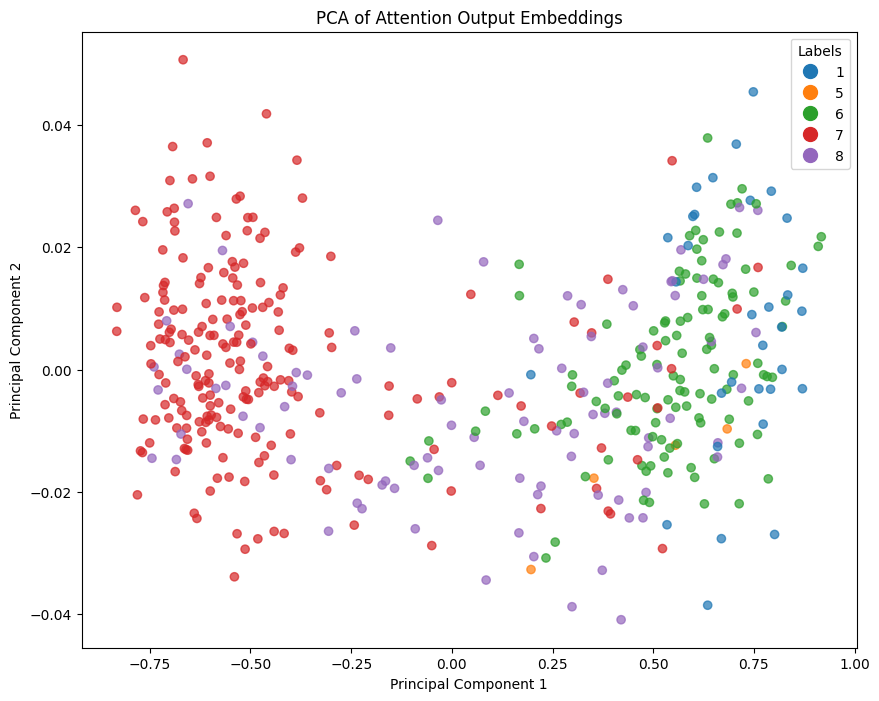

In [33]:
from sklearn.decomposition import PCA
import numpy as np

batch_idx = 0
attn_output_batch = att_map[:, batch_idx, :]  # Shape: (sequence length, embedding dimension)
print(attn_output_batch.shape)

# Print some embeddings
# print("Embeddings for the first few elements in the sequence:")
# print(attn_output_batch[:5, :])  # Print embeddings for the first 5 elements

# Use PCA to reduce dimensionality to 2D for visualization
pca = PCA(n_components=2)
attn_output_reduced = pca.fit_transform(attn_output_batch.detach().numpy())
labels = np.argmax(pyg_data_val[2].y, axis=1).numpy()
assert len(labels) == attn_output_reduced.shape[0], "Mismatch between labels and embeddings"

# Map each label to a color from the colormap
cmap = plt.get_cmap('tab10')
unique_labels = np.unique(labels)
color_map = {label: cmap(i) for i, label in enumerate(unique_labels)}

# Map labels to colors
point_colors = [color_map[label] for label in labels]

# Plot the reduced embeddings with colors according to their labels
plt.figure(figsize=(10, 8))
scatter = plt.scatter(attn_output_reduced[:, 0], attn_output_reduced[:, 1], c=point_colors, alpha=0.7)

# Create a legend
handles = [plt.Line2D([0], [0], marker='o', color=color_map[label], linestyle='', markersize=10) for label in unique_labels]
plt.legend(handles, unique_labels, title='Labels')

plt.title("PCA of Attention Output Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Idea: 
- color cells by cell type or niches# Select a batch for analysis (e.g., batch 0)
- apply Leiden clustering on cells, what kind of niches do we find?
- How far away are cells on average?

### Similarity between Embeddings

Compute the similarity (e.g., cosine similarity) between different embeddings in the attn_output to see which elements of the sequence are represented similarly after attention.

In [ ]:
import torch.nn.functional as F

# Select a batch for analysis (e.g., batch 0)
batch_idx = 0
attn_output_batch = att_map[:, batch_idx, :]  # Shape: (sequence length, embedding dimension)

# Compute Cosine Similarity
cosine_similarity_matrix = F.cosine_similarity(
    attn_output_batch.unsqueeze(1),  # Shape: (sequence length, 1, embedding dimension)
    attn_output_batch.unsqueeze(0),  # Shape: (1, sequence length, embedding dimension)
    dim=2
)  # Shape: (sequence length, sequence length)

# Print the Cosine Similarity Matrix
print("Cosine Similarity Matrix:")
print(cosine_similarity_matrix)

sequence_length = 457 # ToDo: adjust flexible

# Visualize the Cosine Similarity Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cosine_similarity_matrix.detach().numpy(), annot=True, cmap='viridis', xticklabels=range(sequence_length), yticklabels=range(sequence_length))
plt.title("Cosine Similarity Matrix of Attention Output Embeddings")
plt.xlabel("Sequence Element")
plt.ylabel("Sequence Element")
plt.show()